In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *
#from netmap.downstream.final_downstream import *
from netmap.downstream.plotting import *

from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path


In [2]:
from netmap.masking.internal import *
from netmap.downstream.regulon import select_top_edges_signed


In [3]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/cd8tcells.h5ad')
experiment_name = 'cd8_tcells'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/cd8_usecase_low_ui/"
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)

In [4]:
analysis_output_dir = op.join(output_dir, )
grn_output_dir = Path(op.join(output_dir, "grn"))


In [ ]:
grn_adata = retrieve_top_edges(grn_adata, grn_output_dir, percentage=0.1 )

In [ ]:
adata_raw.layers['counts']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7353291 stored elements and shape (42589, 785)>

In [ ]:
sc.tl.pca(adata_raw, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(adata_raw, n_neighbors = 50)
sc.tl.umap(adata_raw, n_components =50)
sc.tl.leiden(adata_raw, resolution=0.15)


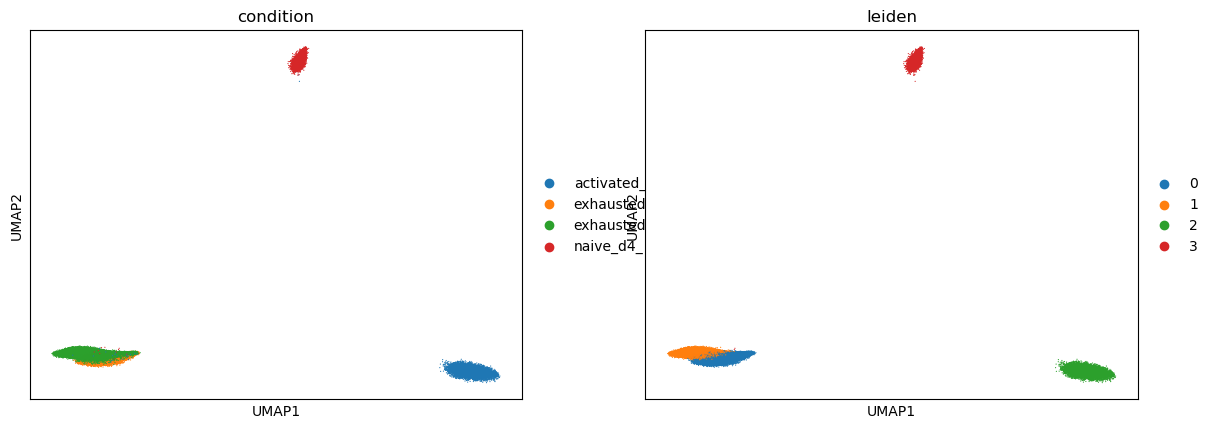

In [ ]:
sc.pl.umap(adata_raw, color = ['condition', 'leiden'])

In [ ]:
grn_adata.var = grn_adata.var.set_index('index')



In [ ]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)
sc.tl.tsne(grn_adata)


In [ ]:
sc.tl.leiden(grn_adata, resolution=0.1)

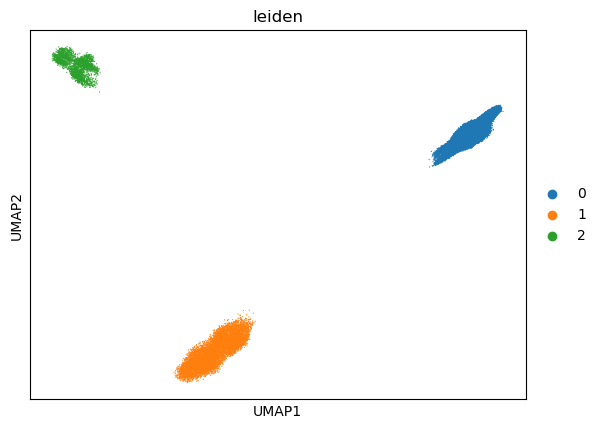

In [ ]:
sc.pl.umap(grn_adata, color = 'leiden')

In [ ]:
print("\nClustering Score Evaluation")
for col_grn in ["leiden"]:
    score = unify_group_labelling( adata_raw, grn_adata, 'condition', col_grn)
    print(f"{col_grn} score: {score}")


Clustering Score Evaluation
leiden score: (np.float64(0.6693747211721337), {'0': 'exhausted_d3_', '1': 'activated_d1_', '2': 'naive_d4_'})


In [ ]:
adata_raw.obs['leiden_remap'] = grn_adata.obs['leiden_remap'].values


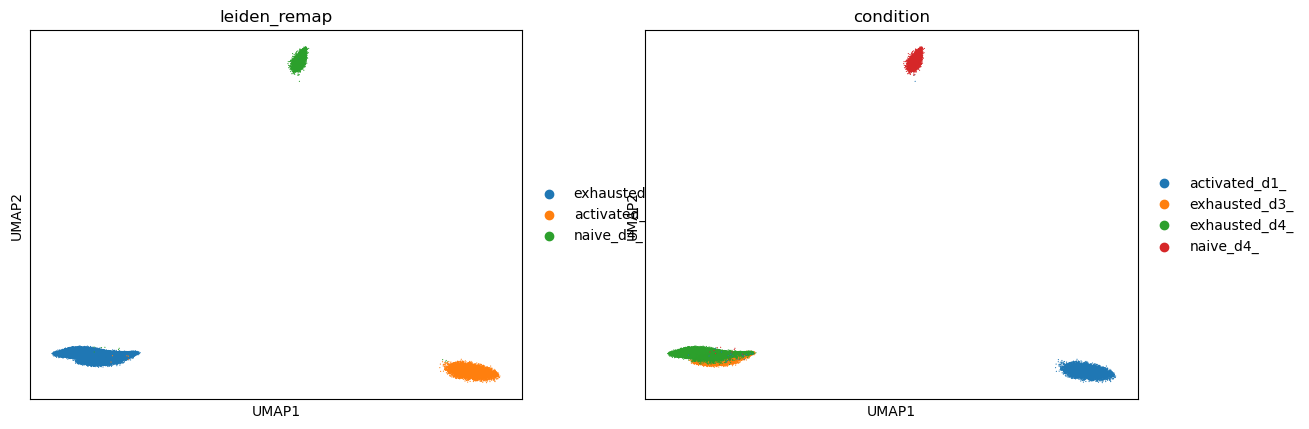

In [ ]:
sc.pl.umap(adata_raw, color = ['leiden_remap', 'condition'])

In [ ]:
grn_adata2 = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)
grn_adata2.var = grn_adata2.var.set_index('index')

In [ ]:
grn_adata2.obs = grn_adata.obs

In [ ]:
add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts' )
grn_adata2 = add_cluster_based_candidate_edges(grn_adata2, threshold=0.5, cluster_column='leiden')


In [ ]:
index_list = np.where(grn_adata2.var['candidate_edge'])[0]
grn_adata3 = retrieve_edges_by_index(grn_adata2, grn_output_dir, index_list)

In [ ]:

grn_adata3.obs = grn_adata2.obs
grn_adata3.obsm['X_pca'] = grn_adata.obsm['X_pca']
grn_adata3.obsm['X_umap'] = grn_adata.obsm['X_umap']
grn_adata3.obsm['X_tsne'] = grn_adata.obsm['X_tsne']

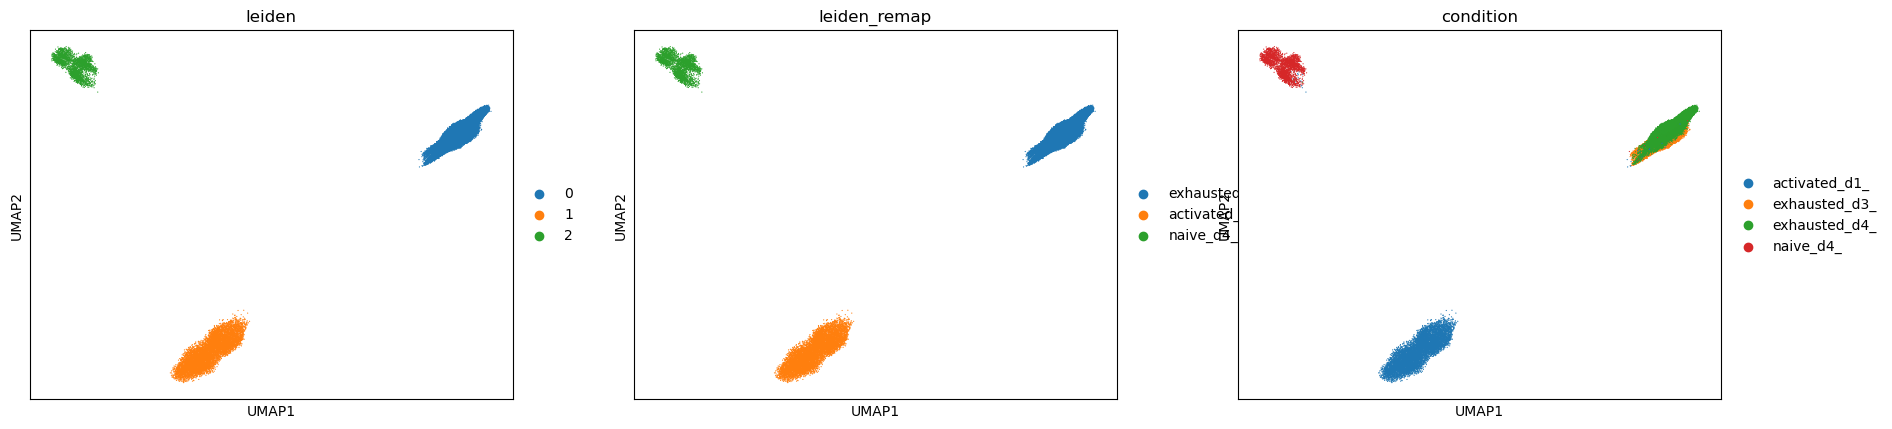

In [ ]:
sc.pl.umap(grn_adata3, color = ['leiden', 'leiden_remap', 'condition'])

In [ ]:
# This adds the information from the collectri GRN (it will add the columns 'is_source_collectri')
grn_adata3 = add_external_grn(grn_ad=grn_adata3,   external_grn=collectri,name_grn='collectri')

In [ ]:
# Identify top targets for each source gene within clusters
# - Keeps up to top_per_source strongest targets
# - Removes regulons smaller than min_reg_size
cluster_column = 'leiden'
top_per_source = 30
min_reg_size = 3
add_neighbourhood_expression_mask(adata_raw, grn_adata3, strict=False, layer = 'counts' )
# 'Discovery mode' : Every source can be a 'regulator'
keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=top_per_source, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True, min_edge_support=0.5)


# Targeted mode: Only known TFs (or genes of your choice can be regulators) 
# Edge support means, that an edge needs to be 'manifestable' in at least p% of the edges in that cluster
# You can also add your own boolean mask and add it instead of the edge column.
#keep_edges = select_top_edges(gene_inter_adata=grn_adata3, adata=adata_raw, top_per_source=top_per_source, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True, tf_column='is_source_collectri', min_edge_support=0.2)



Selecting targets for cluster: 0
Selecting targets for cluster: 1
Selecting targets for cluster: 2


In [ ]:
# This makes a data frame out of the regulon dictionary.
all_regulons = make_cluster_regulon_dataframe(keep_edges)
all_regulons.to_csv(op.join(analysis_output_dir, 'regulons.tsv'), sep = '\t')

In [ ]:
# Computes the mean of the edges per regulon
regus = aggregate_edges(keep_edges, grn_adata3, key='unique')

0
1
2


In [ ]:
all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
all_signatures.obs['leiden_remap'] = grn_adata3.obs['leiden_remap'].values


In [ ]:
grn_adata3.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
all_signatures.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

In [ ]:
cluster_column = 'leiden_remap'

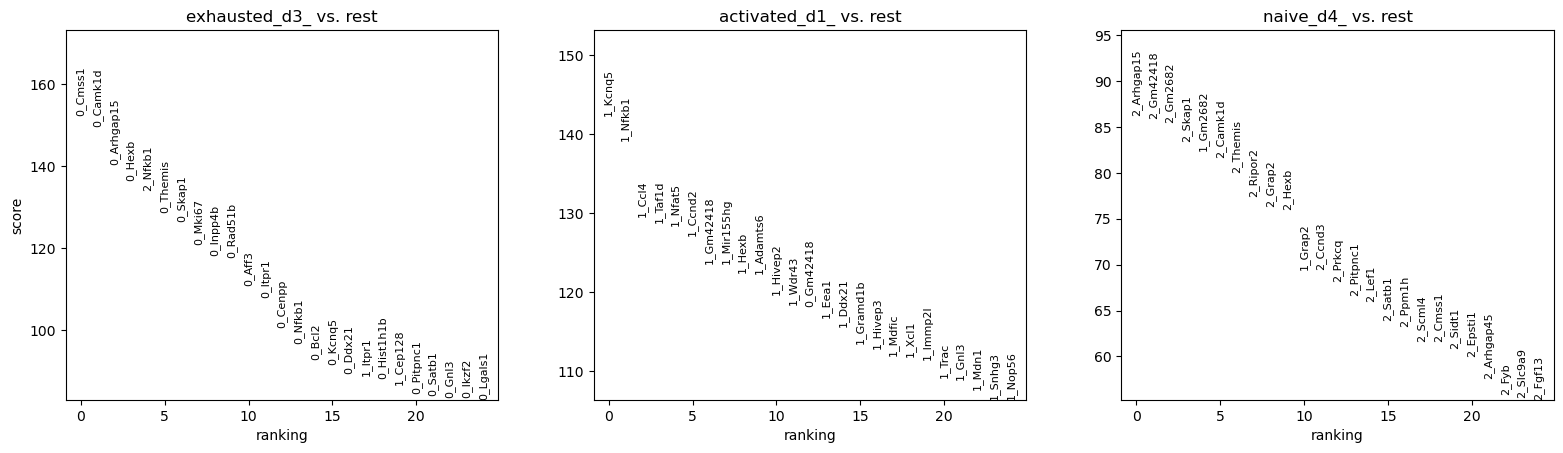

In [ ]:

# Compute differential regulon activity using the nonparametric Wilcoxon test.
# This identifies regulons whose activity significantly differs between clusters.
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")

# Visualize the top differentially active regulons per cluster.
# The plot shows effect sizes and significance for the highest-ranked regulons.
sc.pl.rank_genes_groups(all_signatures, n_genes=25, sharey=False, key="wilcoxon")

In [ ]:
pp = rank_regulon_groups_dotplot(grn_adata3, adata_regl=all_signatures, return_fig=True, new_cluster_column='leiden_remap', original_cluster_column='condition', n_genes=10)

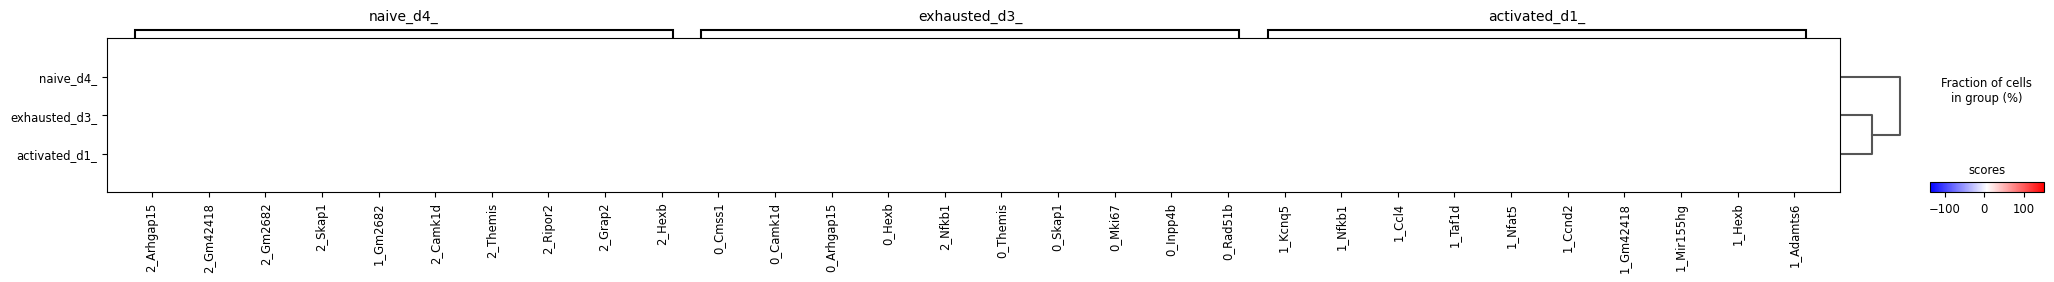

In [ ]:
pp.show()

In [ ]:
pp = sc.pl.rank_genes_groups_dotplot(all_signatures, key = 'wilcoxon', return_fig=True, n_genes=10)

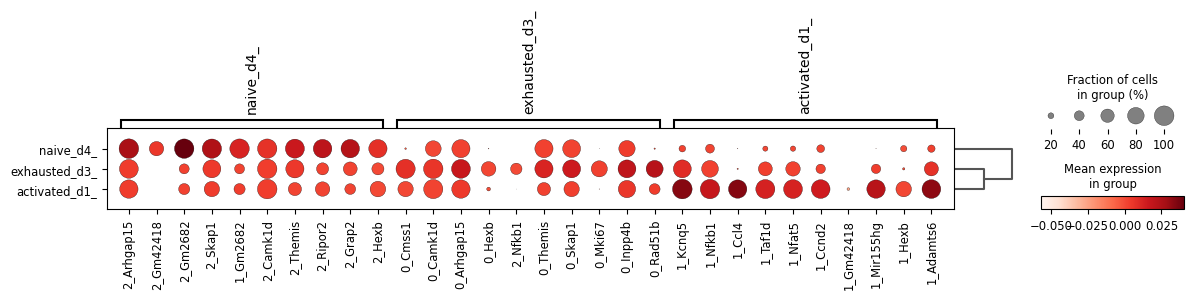

In [ ]:
pp.show()

In [ ]:
all_signatures.obs

,cell_id,condition,barcode,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,...,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,leiden,leiden_remap
1,AAACAGCCAAGTCGCT-1,exhausted_d3_,exhausted_d3_AAACAGCCAAGTCGCT-1,1057,6.964136,1154.760010,7.052514,10.238612,17.249309,29.544821,...,0.0,0.0,52.331223,3.976522,4.531783,0.000000,0.000000,0.000000,0,exhausted_d3_
3,AAACAGCCAATCCTGA-1,exhausted_d3_,exhausted_d3_AAACAGCCAATCCTGA-1,786,6.668228,1068.080078,6.974554,10.859371,19.269902,31.038087,...,0.0,0.0,41.422657,3.747683,3.878235,1.256940,0.814010,0.117682,0,exhausted_d3_
4,AAACAGCCACAAAGCG-1,exhausted_d3_,exhausted_d3_AAACAGCCACAAAGCG-1,1791,7.491088,1372.912109,7.225418,8.236925,13.207325,21.773320,...,0.0,0.0,45.502716,3.839511,3.314321,0.609354,0.475833,0.044384,0,exhausted_d3_
5,AAACAGCCACACTAAT-1,exhausted_d3_,exhausted_d3_AAACAGCCACACTAAT-1,2537,7.839132,1405.645630,7.248963,8.150983,12.765966,20.532528,...,0.0,0.0,46.741779,3.865807,3.325289,0.656573,0.504751,0.046710,0,exhausted_d3_
6,AAACAGCCACGTAATT-1,exhausted_d3_,exhausted_d3_AAACAGCCACGTAATT-1,670,6.508769,945.713562,6.852997,12.999680,22.617504,36.572103,...,0.0,0.0,56.286514,4.048065,5.951751,1.276272,0.822539,0.134953,0,exhausted_d3_
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10153,TTTGTGGCACATACTG-1,naive_d4_,naive_d4_TTTGTGGCACATACTG-1,1156,7.053586,1242.761963,7.125896,9.766762,16.627760,27.966568,...,0.0,0.0,10.582696,2.449512,0.851547,0.881891,0.632277,0.070962,3,naive_d4_
10164,TTTGTGTTCTAATCCT-1,naive_d4_,naive_d4_TTTGTGTTCTAATCCT-1,728,6.591674,968.776672,6.877066,13.428907,22.287916,36.480280,...,0.0,0.0,13.343728,2.663313,1.377379,0.000000,0.000000,0.000000,3,naive_d4_
10166,TTTGTTGGTAGTTAAC-1,naive_d4_,naive_d4_TTTGTTGGTAGTTAAC-1,793,6.677083,1072.695190,6.978861,12.166924,20.737604,36.291567,...,0.0,0.0,9.704820,2.370694,0.904714,0.000000,0.000000,0.000000,3,naive_d4_
10167,TTTGTTGGTCATCAAG-1,naive_d4_,naive_d4_TTTGTTGGTCATCAAG-1,915,6.820016,1114.516968,7.017073,11.087758,18.798173,32.548444,...,0.0,0.0,19.491638,3.020017,1.748887,1.552527,0.937084,0.139300,3,naive_d4_


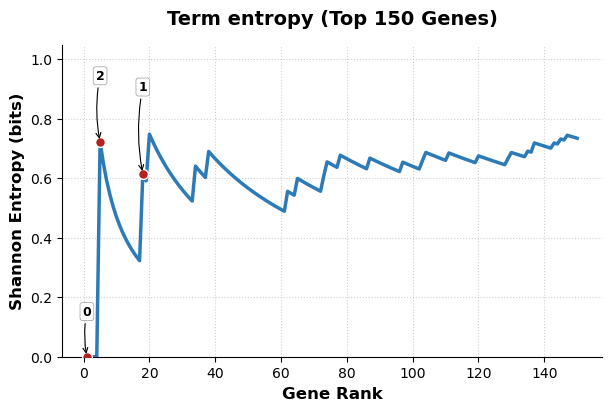

In [ ]:
bcrank = sc.get.rank_genes_groups_df(all_signatures, group=  'exhausted_d3_', key = 'wilcoxon')
bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)
bcrank_entropy(bcrank, top_n=150, title="Term entropy", figsize=(6,4))


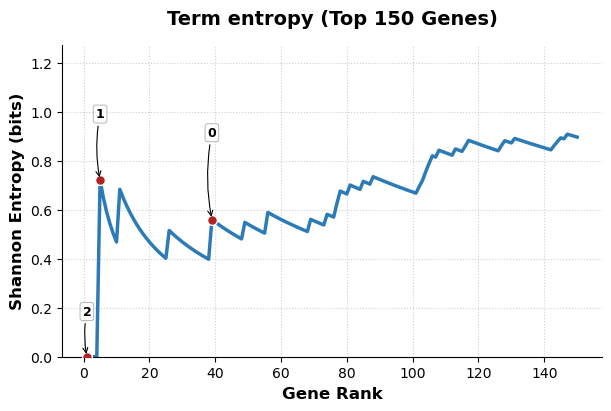

In [ ]:
bcrank = sc.get.rank_genes_groups_df(all_signatures, group=  'naive_d4_', key = 'wilcoxon')
bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)
bcrank_entropy(bcrank, top_n=150, title="Term entropy", figsize=(6,4))


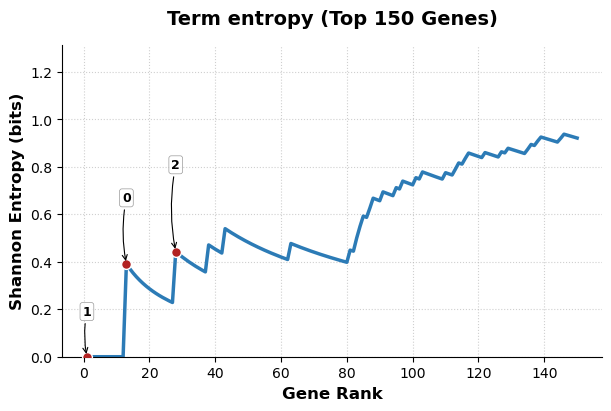

In [ ]:
bcrank = sc.get.rank_genes_groups_df(all_signatures, group=  'activated_d1_', key = 'wilcoxon')
bcrank[['celltype', 'gene']] = bcrank['names'].str.rsplit('_', n=1, expand=True)
bcrank_entropy(bcrank, top_n=150, title="Term entropy", figsize=(6,4))


In [ ]:
all_signatures.var

,regulon_name,source
0_4930523C07Rik,0_4930523C07Rik,4930523C07Rik
0_4933406I18Rik,0_4933406I18Rik,4933406I18Rik
0_Abtb2,0_Abtb2,Abtb2
0_Adamts6,0_Adamts6,Adamts6
0_Adcy7,0_Adcy7,Adcy7
...,...,...
2_Zeb1,2_Zeb1,Zeb1
2_Znrf1,2_Znrf1,Znrf1
2_Znrf2,2_Znrf2,Znrf2
2_Znrf3,2_Znrf3,Znrf3


(<Figure size 400x400 with 3 Axes>,
 <Axes: xlabel='0_Camk1d', ylabel='0_Arhgap15'>)

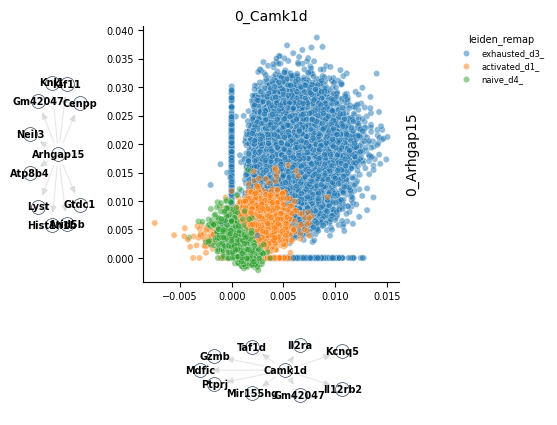

In [ ]:
# Make plot with the regulon values and the GRN on the axis.
plot_regulon_comparison(all_signatures, all_regulons, ['0_Camk1d','0_Arhgap15' ])

In [ ]:
import scanpy as sc
import os.path as op

In [7]:
grn_adata3 = sc.read_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
all_signatures = sc.read_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))

In [8]:
from netmap.masking.internal import add_cluster_wise_spearman
from netmap.downstream.regulon import select_top_edges_signed

# Step 1: annotate edges with cluster-wise Spearman correlation
grn_adata = add_cluster_wise_spearman(grn_adata3, adata_raw, cluster_column='leiden_remap')

# Step 2: select signed regulons

keep_edges_positive = select_top_edges_signed(
    grn_adata,
    top_per_source=10,
    col_cluster='leiden_remap',
    min_reg_size=1,
     min_edge_support=0.5,
    neutral_threshold=0.05,
)



Selecting targets for cluster: activated_d1_
Selecting targets for cluster: exhausted_d3_
Selecting targets for cluster: naive_d4_


In [ ]:
# This function can be used to transform the dictionary into a dataframe. 
all_regulons = make_cluster_regulon_dataframe_directional(keep_edges_positive)
